Audio Processing using python

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

In [9]:
audio_path = "/content/sample1audio.mp3"

In [8]:
y, sr = librosa.load(audio_path, sr=None)

In [10]:
y

array([-4.3402193e-05, -3.7663747e-05, -3.2929383e-06, ...,
       -7.4131851e-05,  4.3866345e-05,  3.8816754e-05], dtype=float32)

In [11]:
y[:10]

array([-4.3402193e-05, -3.7663747e-05, -3.2929383e-06,  6.8048641e-05,
        1.8051524e-04,  3.3205585e-04,  5.1401160e-04,  7.1385392e-04,
        9.2000299e-04,  1.1205431e-03], dtype=float32)

In [12]:
y.shape

(563712,)

In [13]:
sr

44100

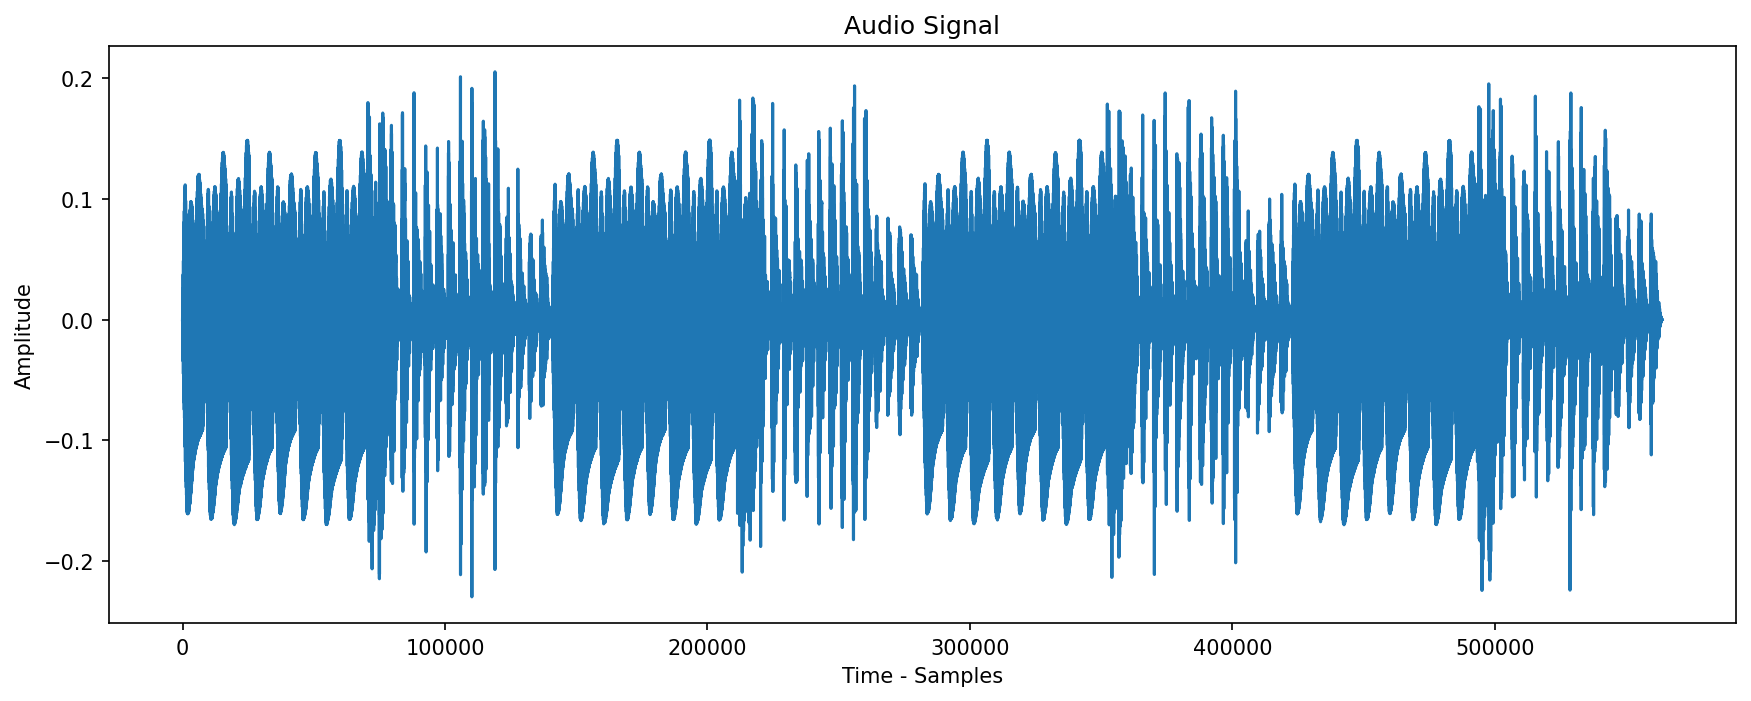

In [14]:
plt.figure(figsize=(14,5), dpi=150)
plt.plot(y)
plt.xlabel("Time - Samples")
plt.ylabel("Amplitude")
plt.title("Audio Signal")
plt.show()

In [15]:
from IPython.display import Audio

In [16]:
Audio(data=y,rate=sr)

DFT Discrete Fourier Transform

In [17]:
window = np.hanning(len(y))
windowed_input = y* window
dft = np.fft.rfft(windowed_input)

In [18]:
dft

array([-5.06703510e+03+0.00000000e+00j,  2.54154541e+03+1.52487952e+01j,
       -8.44712135e+00-2.17750471e+01j, ...,
        1.11422717e-04-6.88906485e-05j,  1.18981852e-04+7.80241045e-05j,
       -3.59071896e-04+0.00000000e+00j])

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


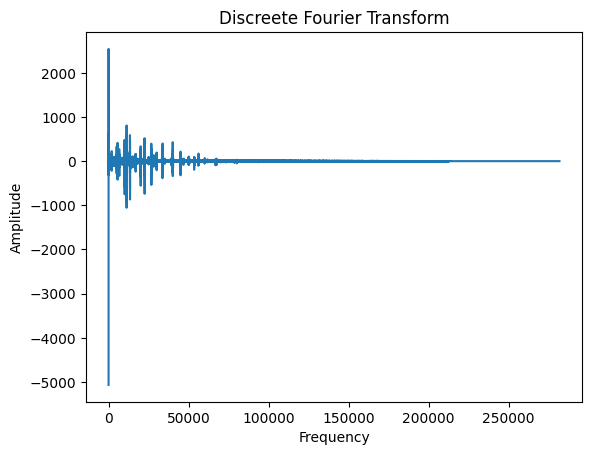

In [20]:
plt.plot(dft)
plt.title("Discreete Fourier Transform")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

In [21]:
amplitude = np.abs(dft)


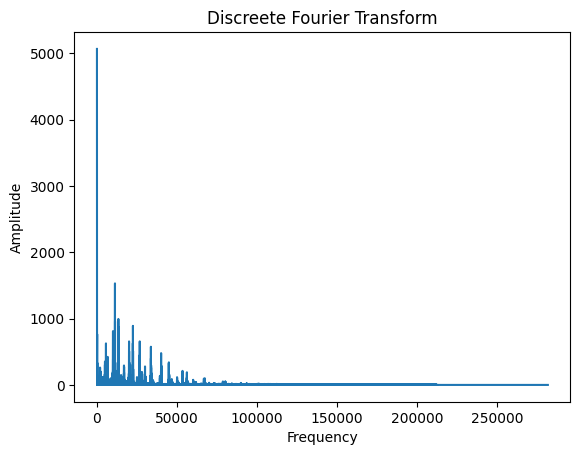

In [22]:
plt.plot(amplitude)
plt.title("Discreete Fourier Transform")
plt.xlabel("Frequency")
plt.ylabel("Amplitude")
plt.show()

In [23]:
amplitude_dB = librosa.amplitude_to_db(amplitude,ref=np.max)

In [24]:
frequency = librosa.fft_frequencies(sr=sr,n_fft=len(y))

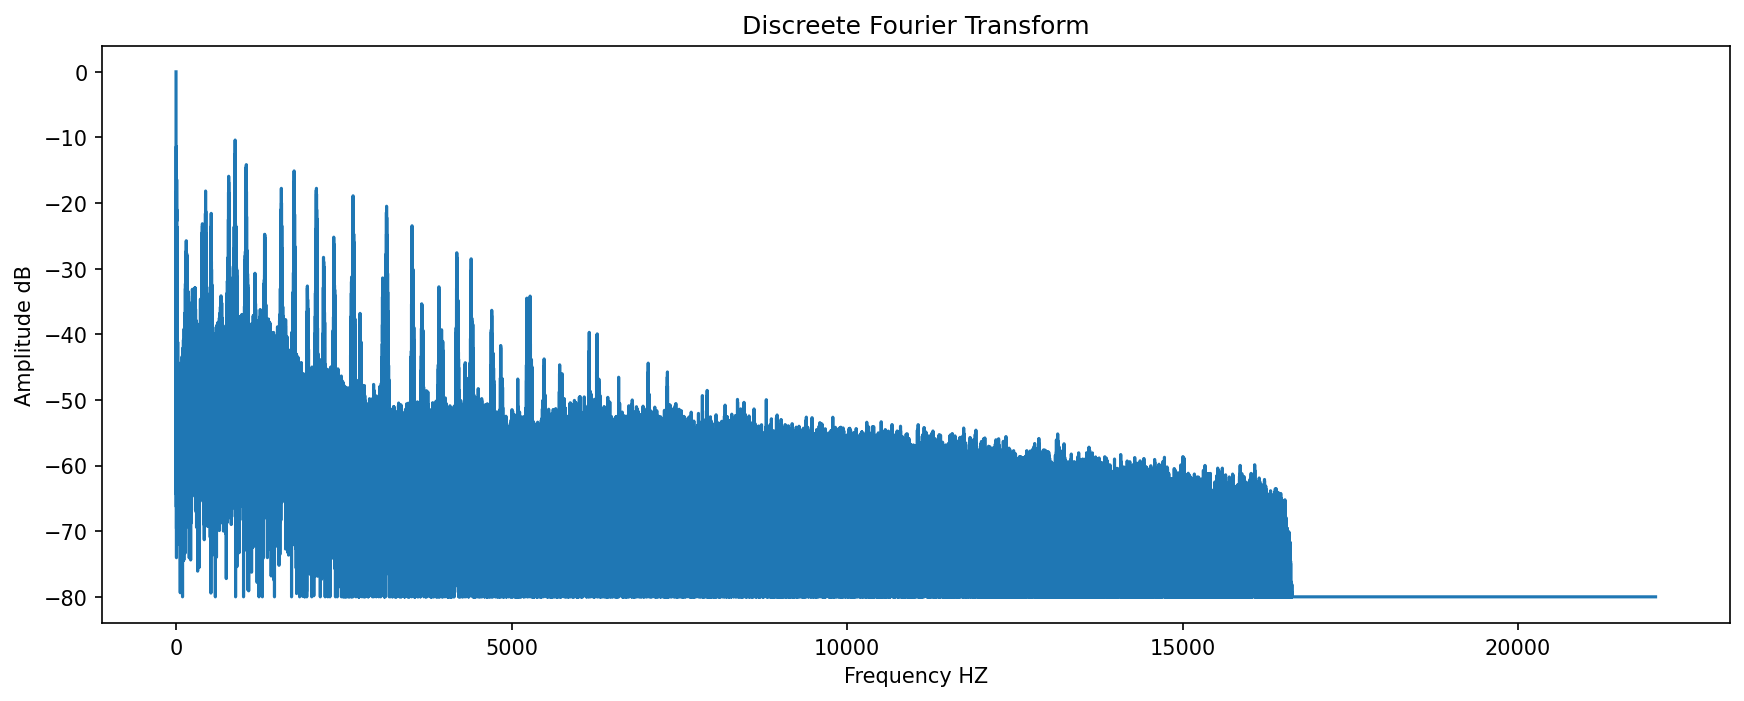

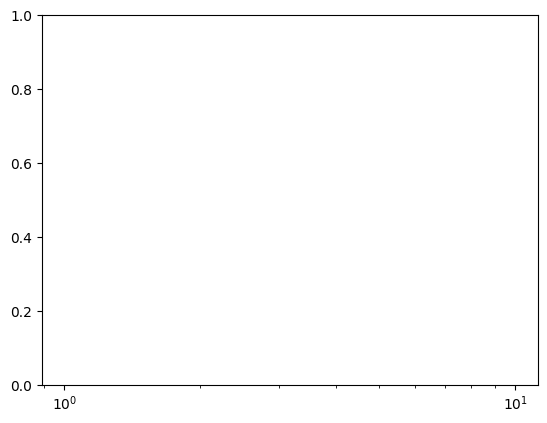

In [26]:
plt.figure(figsize=(14,5), dpi=150)
plt.plot(frequency,amplitude_dB)
plt.title("Discreete Fourier Transform")
plt.xlabel("Frequency HZ")
plt.ylabel("Amplitude dB")
plt.show()
plt.xscale("log")

In [28]:
D = librosa.stft(y)
D_db = librosa.amplitude_to_db(np.abs(D),ref=np.max)

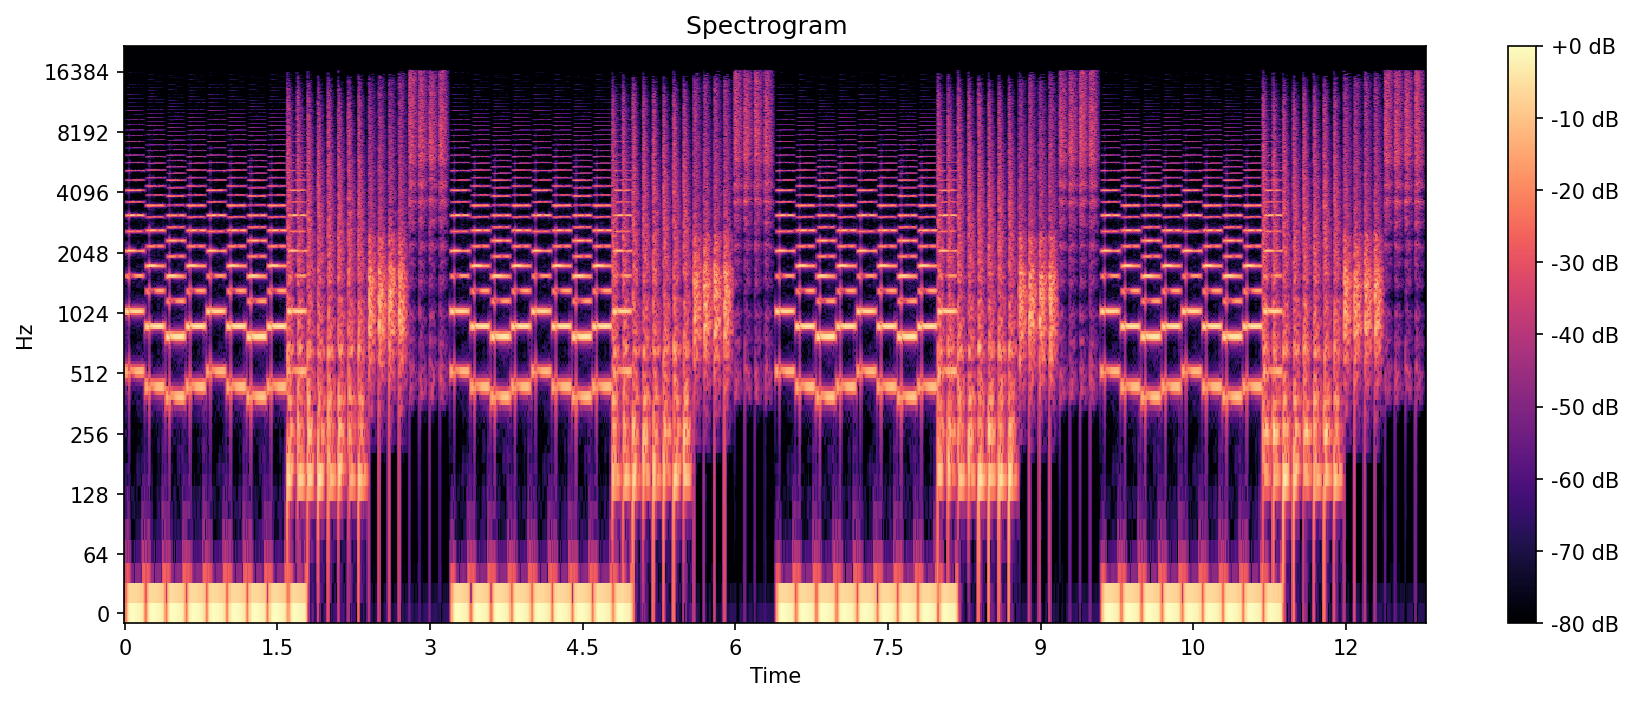

In [30]:
plt.figure(figsize=(14,5), dpi=150)
librosa.display.specshow(D_db, sr=sr, x_axis='time', y_axis='log')
plt.colorbar(format="%+2.0f dB")
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

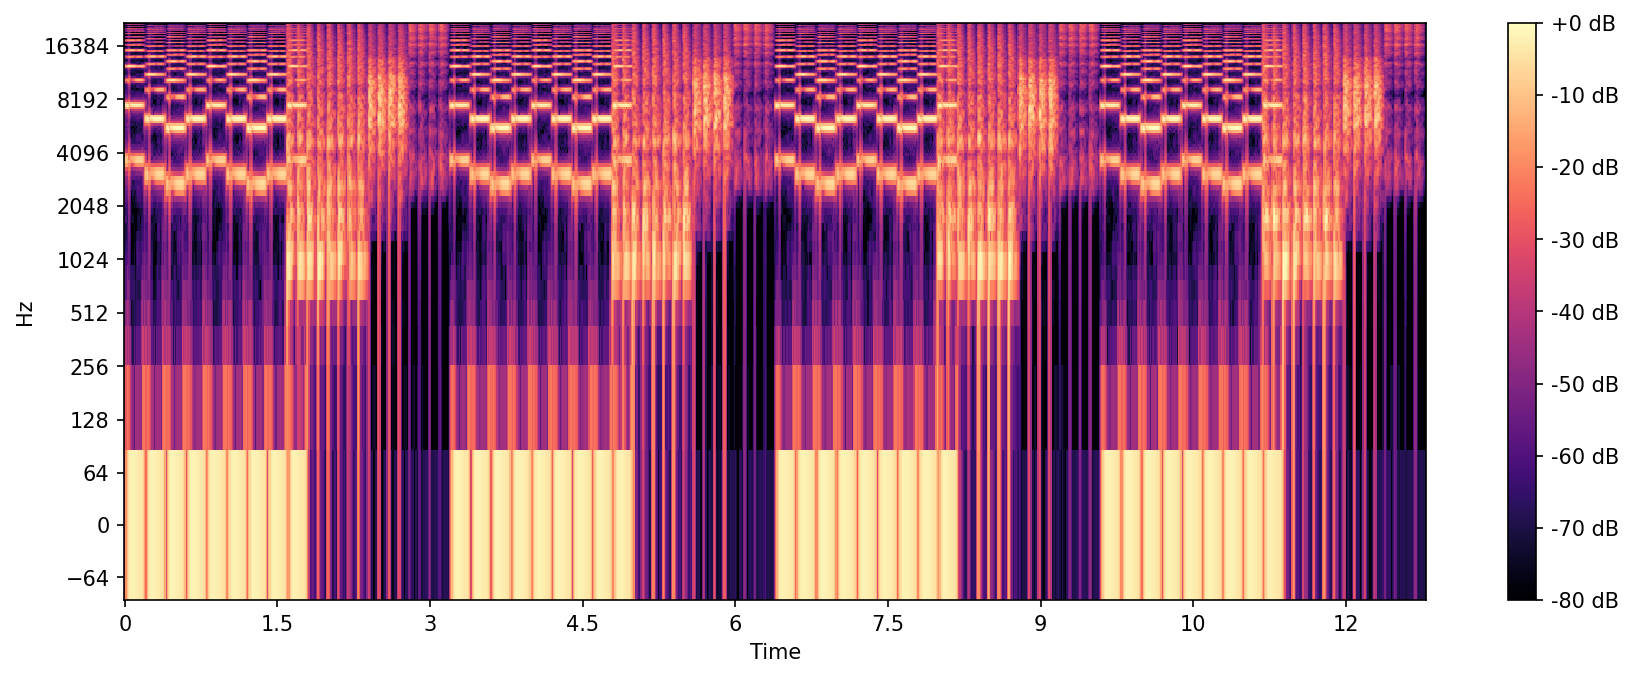

In [31]:
S = librosa.feature.melspectrogram(y=y,sr=sr,n_mels=128,fmax=8000)
S_db = librosa.power_to_db(S,ref=np.max)

plt.figure(figsize=(14,5), dpi=150)
librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log' ,fmax=8000)
plt.colorbar(format="%+2.0f dB")

Import required libraries - Audio Classification

In [32]:
import torch, transformers,torchaudio
print(torch.__version__)
print(transformers.__version__)
print(torchaudio.__version__)

2.11.0+cpu
5.13.1
2.11.0+cpu


Audio Classification

In [ ]:
form transformers import AutoFeatureExtractor ,ASTForAudioClassification